# Raspberry Simple Temperature Reading

Aufs wesentliche reduzierte Temperatur Sensor Auslesung

In [1]:
import subprocess
import sys

def run_on_pico(code: str, port: str = "auto", exec_timeout_s: float = 20.0):
    cmd = [sys.executable, "-m", "mpremote", "connect", port, "exec", code]
    proc = subprocess.run(cmd, capture_output=True, text=True, timeout=exec_timeout_s)
    return proc.stdout.strip(), proc.stderr.strip()

cmd = [sys.executable, "-m", "mpremote", "connect", "list"]
ports = subprocess.run(cmd, capture_output=True, text=True, timeout=10)
print(ports.stdout.strip() or "Keine Ports von mpremote erkannt.")
if ports.stderr.strip():
    print("stderr:\n", ports.stderr.strip())

COM4 E6605481DB4AB137 2e8a:0005 Microsoft None


In [2]:
# Dieser String ist Pico-Code: Er laeuft auf dem MicroPython-Interpreter des Pico (nicht auf dem PC).
# Deshalb stehen machine/utime-Imports hier im String und nicht in der Notebook-Import-Zelle.
code = f'''
from machine import Pin
led = Pin("LED", Pin.OUT)
led.toggle()
'''

out, err = run_on_pico(code)
print(out)


In [5]:
# 2) Messung am Pico starten (interner RP2040-Temperatursensor)
#    Alles im String wird auf dem Pico ausgefuehrt; der Notebook-Python-Code baut nur den String.
code = f'''
from machine import ADC
from utime import sleep

sensor = ADC(4)
raw = sensor.read_u16()
voltage = raw * 3.3 / 65535
temp_c = 27 - (voltage - 0.706) / 0.001721
print(f"{{raw}},{{temp_c:.2f}}")
'''

out, err = run_on_pico(code)
if err.strip():
    raise RuntimeError(err)
print(out)

14131,23.77


In [27]:
def read_raw_and_temp():
    code = '''
from machine import ADC

sensor = ADC(4)
raw = sensor.read_u16()
voltage = raw * 3.3 / 65535
temp_c = 27 - (voltage - 0.706) / 0.001721
print(f"{raw},{temp_c:.2f}")
'''
    out, err = run_on_pico(code)
    r, t = map(float, out.split(","))
    return r,t


In [28]:
read_raw_and_temp()

(14099.0, 24.7)

In [32]:
time_list = list(range(0,11))
print(time_list)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [36]:
from time import sleep
raw_list = []
temp_list = []
for i in time_list:
    r, t = read_raw_and_temp()
    raw_list.append(r)
    temp_list.append(t)
    print(f"{i:2d}: raw={r}, temp={t:.2f}°C")
    sleep(1)

 0: raw=13987.0, temp=27.98°C
 1: raw=13971.0, temp=28.45°C
 2: raw=13987.0, temp=27.98°C
 3: raw=13987.0, temp=27.98°C
 4: raw=13987.0, temp=27.98°C
 5: raw=14003.0, temp=27.51°C
 6: raw=13971.0, temp=28.45°C
 7: raw=13955.0, temp=28.92°C
 8: raw=13923.0, temp=29.85°C
 9: raw=13923.0, temp=29.85°C
10: raw=13907.0, temp=30.32°C


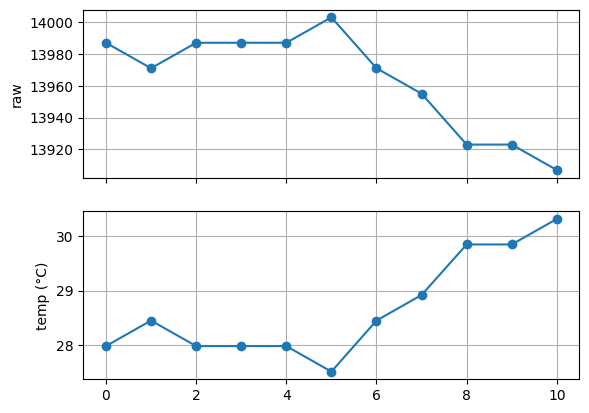

In [38]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2,1, sharex=True)
ax[0].plot(time_list, raw_list, marker="o")
ax[0].set_ylabel("raw") 
ax[1].plot(time_list, temp_list, marker="o")
ax[1].set_ylabel("temp (°C)")
for ax in ax:
    ax.grid()